In [ ]:
from instance_generator import generate_mvc_instance, get_exact_mvc_solution
from problem_encoding import decode_solution
from classical_solvers import greedy_mvc, brute_force_mvc
from quantum_solvers import Montanaro_BB_MVC, Montanaro_BB_MVC_Fast
from visualization import plot_graph_instance, plot_mvc_solution
import networkx as nx


## Version 1 : Montanaro's algorithm with the two subroutines implemented quantumly (with qiskit)



This cell generates a small toy graph

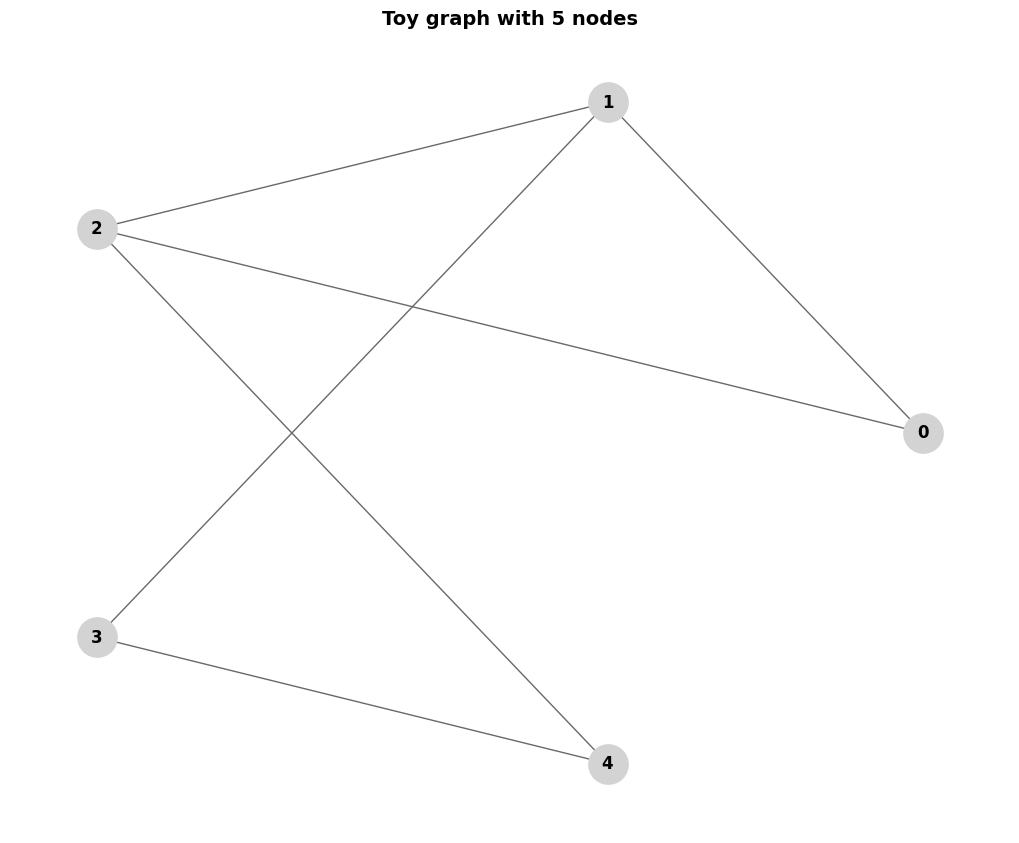

In [4]:

toy_data = generate_mvc_instance(model="toy_5")
G_toy = toy_data['graph']

#plot
plot_graph_instance(G_toy, title="Toy graph with 5 nodes")


This cell generates a small graph instance. It is possible to choose the type of graph and parameters, but in order to have results in a reasonable time with the quantum version, it must be n <= 5

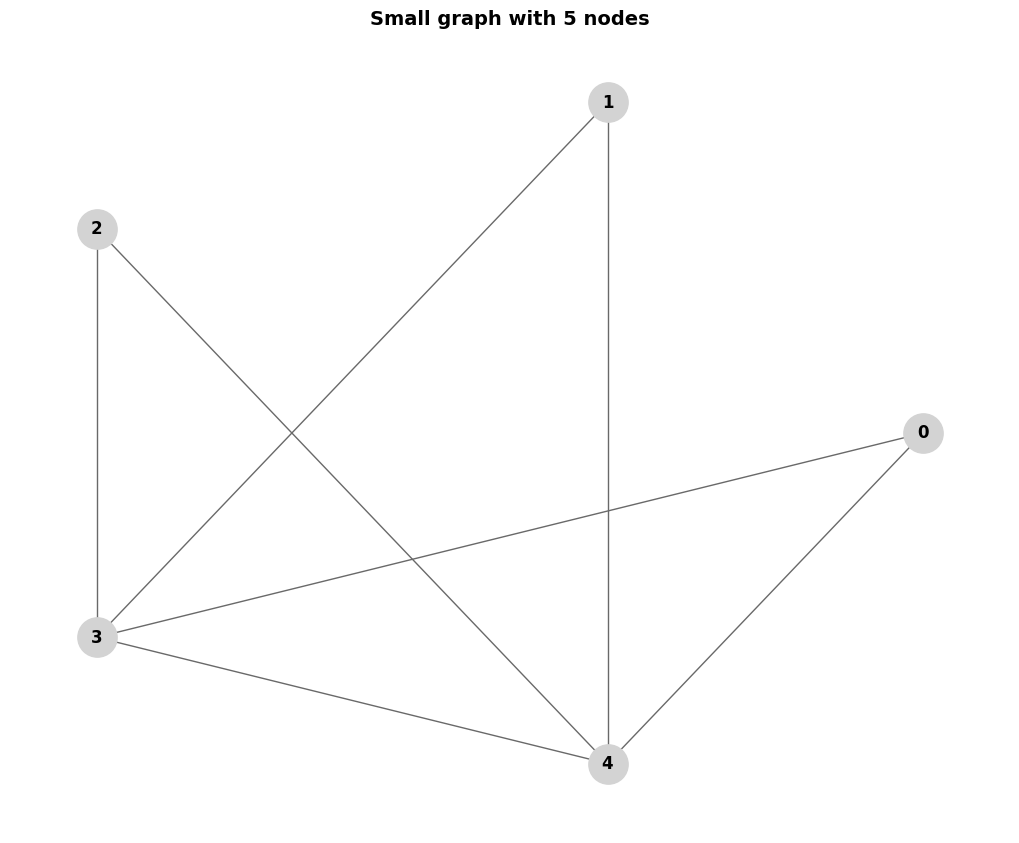

In [22]:
small_graph = generate_mvc_instance(model="erdos_renyi", n=5, p=0.75, seed=2)
#small_graph = generate_mvc_instance(model="barabasi_albert", n=5, m=2, seed=79)
#small_graph = generate_mvc_instance(model="watts_strogatz", n=5, k=2, p=0.5, seed=79)
#small_graph = generate_mvc_instance(model="regular", n=5, d=2, seed=79)

G_small = small_graph['graph']

#plot
plot_graph_instance(G_small, title=f"Small graph with {G_small.number_of_nodes()} nodes")

This cell finds the solution of the MVC problem, using the quantum subroutines. We only use it for a small graph because it takes a lot of time to run.


Starting Montanaro_BB_MVC | Nodes: 5

Tree size limit T = 1
Estimated cost (c_new): 0
No solution found. Doubling T.

Tree size limit T = 2
Estimated cost (c_new): 0
No solution found. Doubling T.

Tree size limit T = 4
Estimated cost (c_new): 1.0
No solution found. Doubling T.

Tree size limit T = 8
Estimated cost (c_new): 1.0
No solution found. Doubling T.

Tree size limit T = 16
Estimated cost (c_new): 3.0
Solution detected. Starting binary search in [1, 3]
Testing cost mid = 2... Failed
Optimal MVC cost found: 3. Recovering state...
Result:
Cost: 3
Vertex cover: [0, 1, 3]


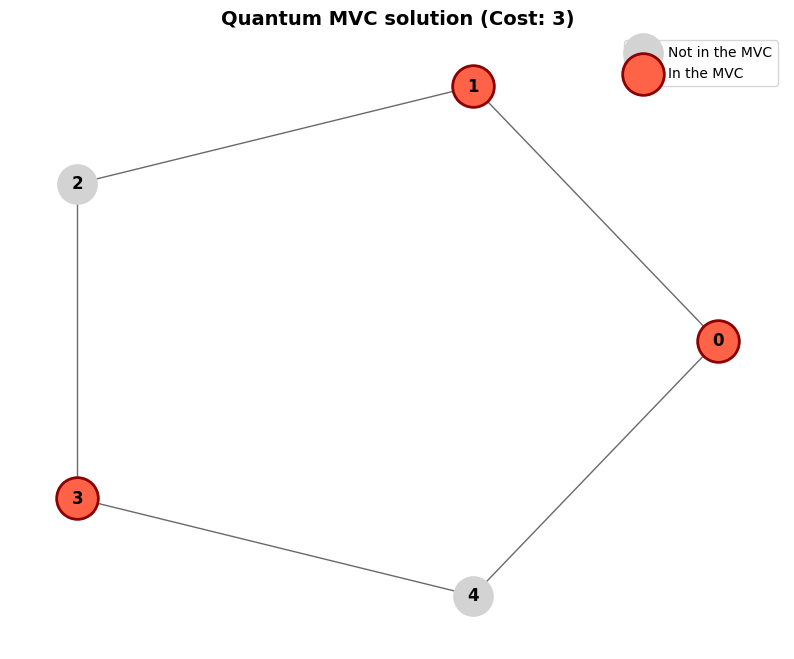

In [20]:
quantum_cost, raw_state_q = Montanaro_BB_MVC(G_small)
quantum_solution = decode_solution(raw_state_q)

print("Result:")
print(f"Cost: {quantum_cost}")
print(f"Vertex cover: {quantum_solution}")

#plot solution
if quantum_cost != "no solution":
    plot_mvc_solution(G_small, quantum_solution, title=f"Quantum MVC solution (Cost: {quantum_cost})")

It it also possible to test the quantum version on larger graphs (up to ~10-15 nodes) with a small MVC size (up to 3 nodes).
This cell generates such a graph, and finds the MVC solution with the quantum version 

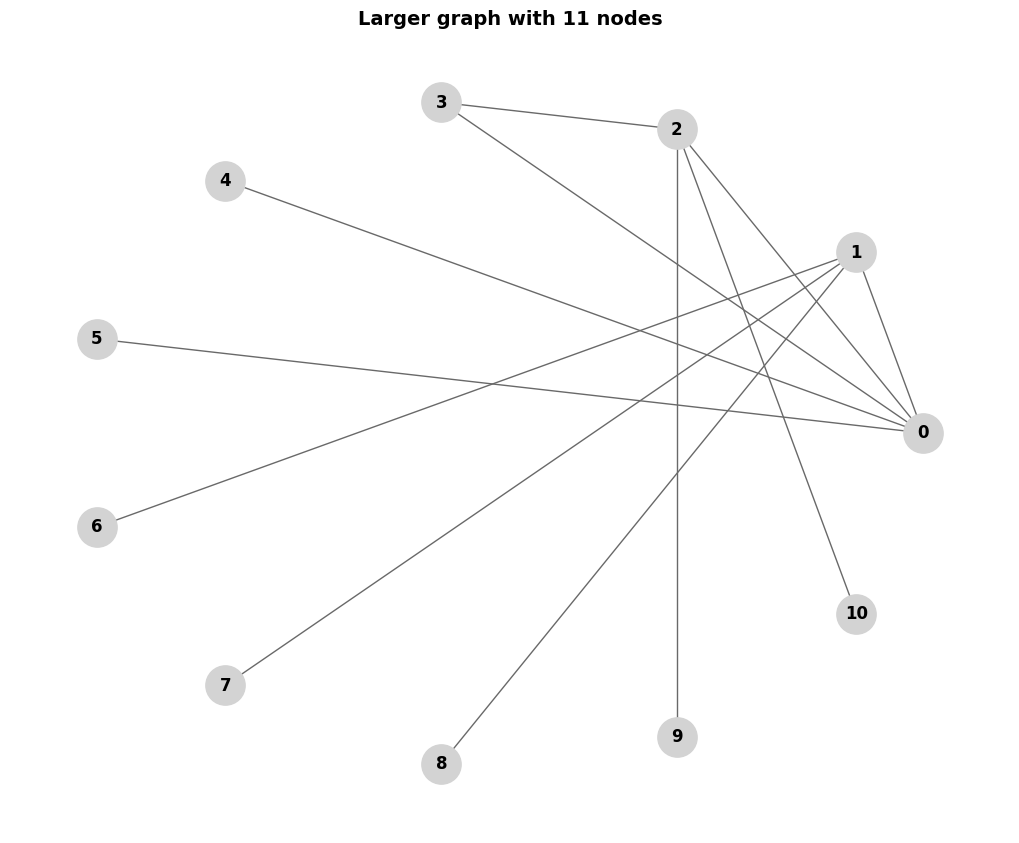


Starting Montanaro_BB_MVC | Nodes: 11

Tree size limit T = 1
Estimated cost (c_new): 0
No solution found. Doubling T.

Tree size limit T = 2
Estimated cost (c_new): 0
No solution found. Doubling T.

Tree size limit T = 4
Estimated cost (c_new): 1.0
No solution found. Doubling T.

Tree size limit T = 8
Estimated cost (c_new): 1.0
No solution found. Doubling T.

Tree size limit T = 16
Estimated cost (c_new): 2.0
No solution found. Doubling T.

Tree size limit T = 32
Estimated cost (c_new): 3.0
Solution detected. Starting binary search in [2, 3]
Testing cost mid = 2... Failed
Optimal MVC cost found: 3. Recovering state...
Result:
Cost: 3
Vertex cover: [0, 1, 2]


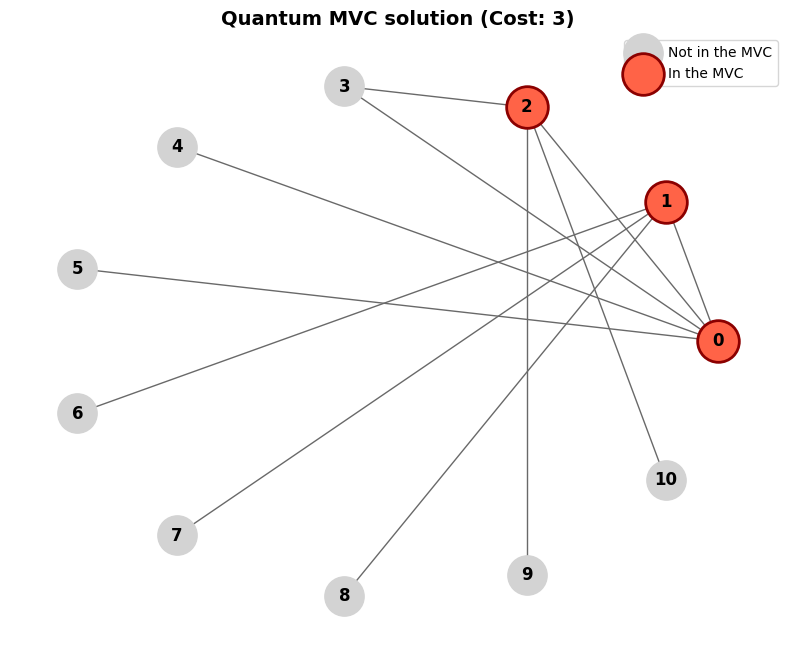

In [37]:
larger_graph_small_mvc = generate_mvc_instance(model="toy_11_mvc_3")
G_larger = larger_graph_small_mvc['graph']
#plot the graph

plot_graph_instance(G_larger, title=f"Larger graph with {G_larger.number_of_nodes()} nodes")
quantum_cost, raw_state_q = Montanaro_BB_MVC(G_larger)
quantum_solution = decode_solution(raw_state_q)

print("Result:")
print(f"Cost: {quantum_cost}")
print(f"Vertex cover: {quantum_solution}")

#plot solution
if quantum_cost != "no solution":
    plot_mvc_solution(G_larger, quantum_solution, title=f"Quantum MVC solution (Cost: {quantum_cost})")

## Version 2 : Montanaro's algorithm with the two subroutines implemented classically
To test Montanaro's algorithm on larger graphs, we replace the quantum circuits with fast classical subroutines. This allows us to validate the logic of the quantum approach while avoiding the exponential execution time.

This cell generates larger instances of graphs. It is possible to choose the type of graph and the parameters.

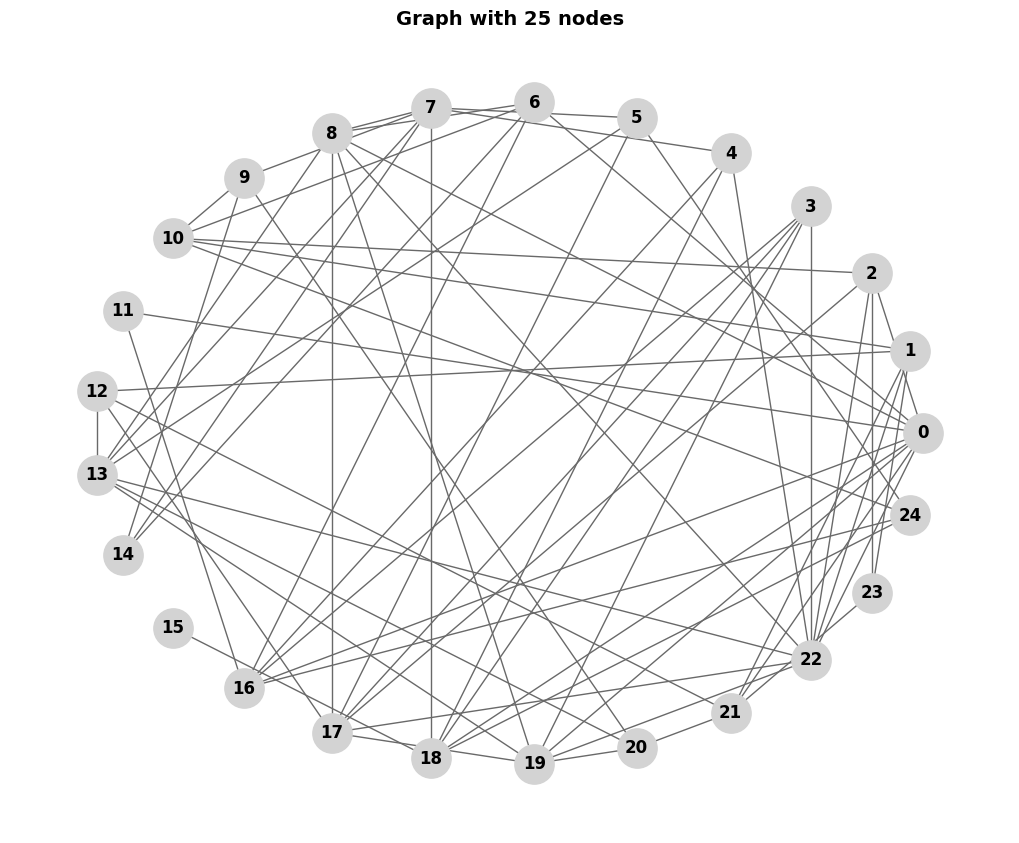

real MVC cost: 14
real MVC solution: [0, 1, 2, 6, 7, 9, 13, 16, 17, 18, 19, 21, 22, 24]


In [23]:
big_graph = generate_mvc_instance(model="erdos_renyi", n=25, p=0.2, seed=48)
#big_graph = generate_mvc_instance(model="regular", n=26, d=2, seed=48)
#big_graph = generate_mvc_instance(model="barabasi_albert", n=30, m=2, seed=48)
#big_graph = generate_mvc_instance(model="watts_strogatz", n=25, k=3, p=0.3, seed=4)

G_big = big_graph['graph']

#plot
plot_graph_instance(G_big, title=f"Graph with {G_big.number_of_nodes()} nodes")

#real MVC solution (to know the optimal cost and solution, to compare our results)
baseline_big_mvc = get_exact_mvc_solution(G_big)
print(f"real MVC cost: {len(baseline_big_mvc)}")
print(f"real MVC solution: {baseline_big_mvc}")


This cell finds the solution of the MVC problem, using the subroutines coded classically to go faster


Starting Montanaro_BB_MVC_Fast | Nodes: 25

Tree size limit T = 1
Estimated cost (c_new): 0
No solution found. Doubling T.

Tree size limit T = 2
Estimated cost (c_new): 0
No solution found. Doubling T.

Tree size limit T = 4
Estimated cost (c_new): 0
No solution found. Doubling T.

Tree size limit T = 8
Estimated cost (c_new): 0
No solution found. Doubling T.

Tree size limit T = 16
Estimated cost (c_new): 1.0
No solution found. Doubling T.

Tree size limit T = 32
Estimated cost (c_new): 2.0
No solution found. Doubling T.

Tree size limit T = 64
Estimated cost (c_new): 2.0
No solution found. Doubling T.

Tree size limit T = 128
Estimated cost (c_new): 3.0
No solution found. Doubling T.

Tree size limit T = 256
Estimated cost (c_new): 5.0
No solution found. Doubling T.

Tree size limit T = 512
Estimated cost (c_new): 6.0
No solution found. Doubling T.

Tree size limit T = 1024
Estimated cost (c_new): 7.0
No solution found. Doubling T.

Tree size limit T = 2048
Estimated cost (c_new): 

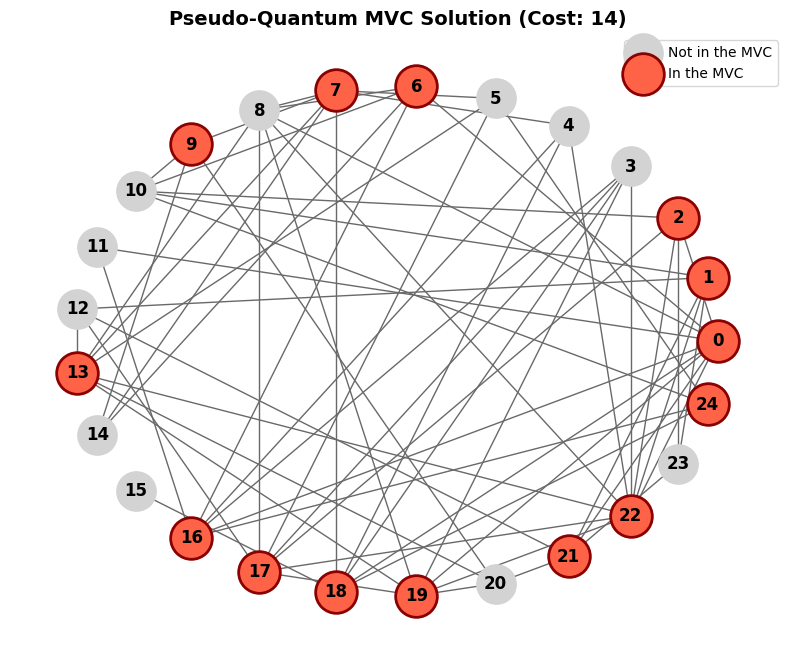

In [24]:
fast_cost, raw_state_fast = Montanaro_BB_MVC_Fast(G_big)
fast_solution = decode_solution(raw_state_fast)

print("Results")
print(f"Cost of the MVC: {fast_cost}")
print(f"MVC solution: {fast_solution}")

#plot
if fast_cost != "no solution":
    plot_mvc_solution(G_big, fast_solution, title=f"Pseudo-Quantum MVC Solution (Cost: {fast_cost})")

## Classical solvers

This cell finds the MVC solution found by the greedy algorithm. It uses the same graph that is generated in the previous section.

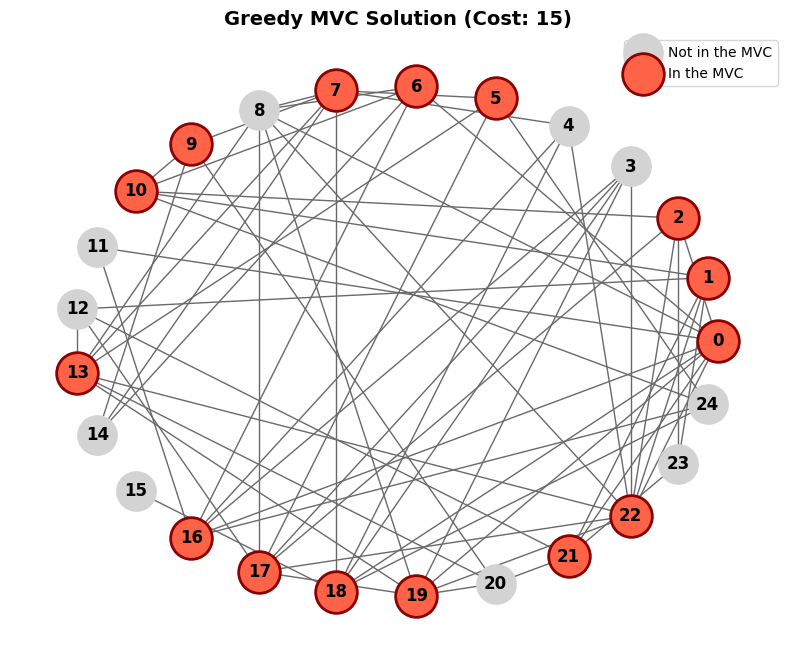

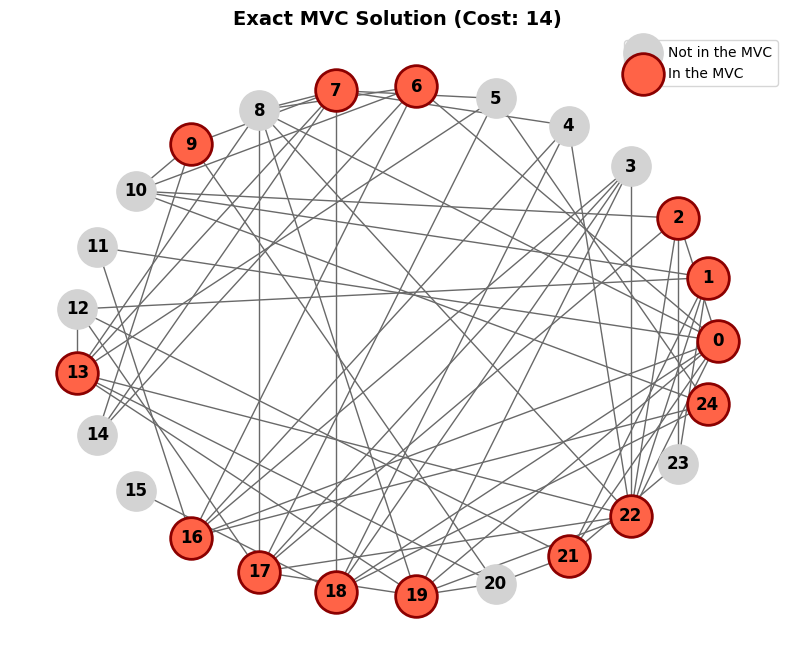

In [28]:
#Greedy algorithm for the MVC problem
#selects iteratively the vertex with the highest degree and removes its edges until the graph has no more edges
#so in the MVC we take each time the most connected vertex

sol_greedy, cost_greedy = greedy_mvc(G_big)

#optimal solution
baseline_big_mvc = get_exact_mvc_solution(G_big)
cost_exact = len(baseline_big_mvc)


#Plot the greedy solution
plot_mvc_solution(G_big, sol_greedy, title=f"Greedy MVC Solution (Cost: {cost_greedy})")

# Plot the exact optimal solution
plot_mvc_solution(G_big, baseline_big_mvc, title=f"Exact MVC Solution (Cost: {cost_exact})")



This cell finds the MVC solution found by the greedy algorithm, on a graph built to trap it.

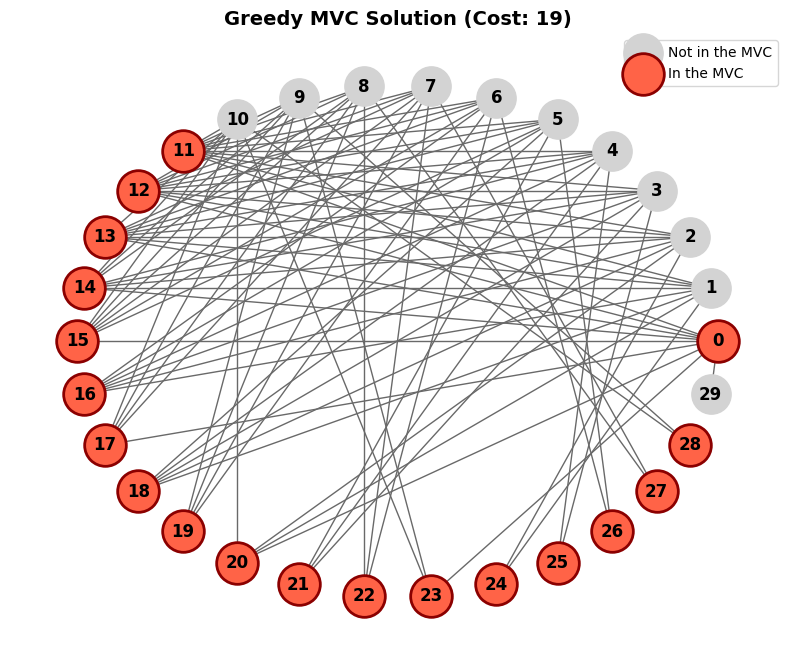

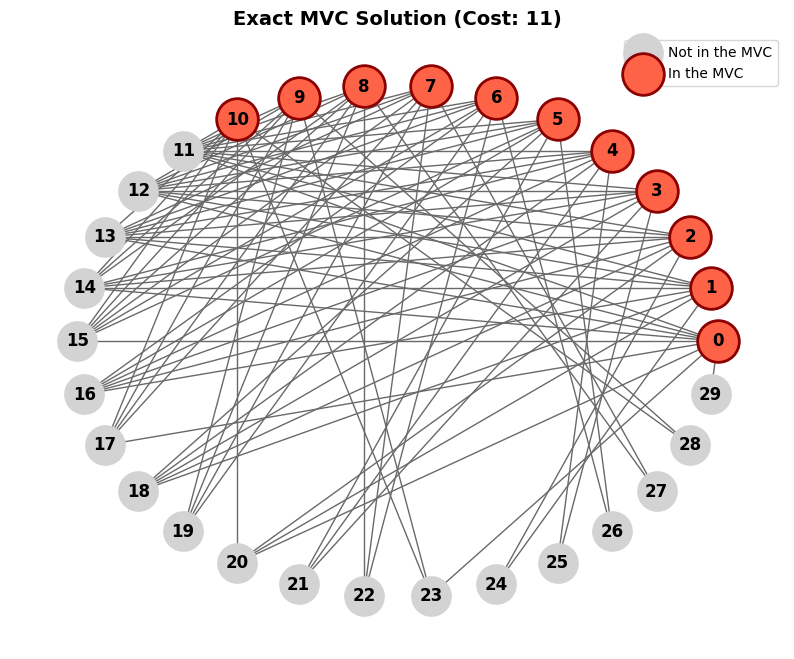

In [31]:
graph_trap_greedy = generate_mvc_instance(model="greedy_trap_30")
G_trap_greedy = graph_trap_greedy['graph']

sol_greedy, cost_greedy = greedy_mvc(G_trap_greedy)

#optimal solution
baseline_big_mvc = get_exact_mvc_solution(G_trap_greedy)
cost_exact = len(baseline_big_mvc)


#Plot the greedy solution
plot_mvc_solution(G_trap_greedy, sol_greedy, title=f"Greedy MVC Solution (Cost: {cost_greedy})")

# Plot the exact optimal solution
plot_mvc_solution(G_trap_greedy, baseline_big_mvc, title=f"Exact MVC Solution (Cost: {cost_exact})")



This cell finds the MVC Solution with the brute force algorithm. It uses the same graph that is generated earlier

MVC cost : 14
MVC Solution : [0, 1, 2, 6, 7, 9, 13, 16, 17, 18, 19, 21, 22, 24]


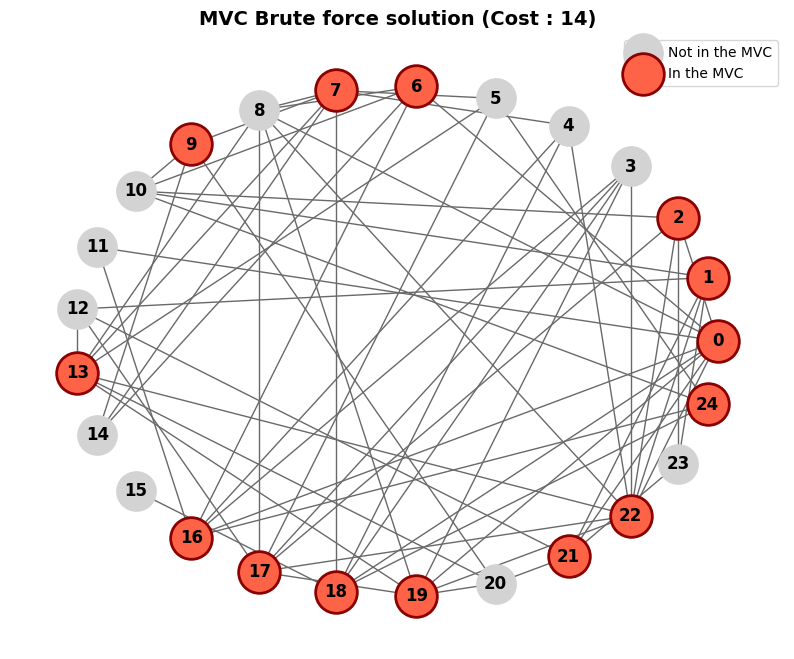

In [ ]:
#Brute force algorithm for the MVC problem
#generates all possible subsets of vertices in increasing order of size
#the first subset that covers all edges is guaranteed to be the minimum

sol_brute, cost_brute = brute_force_mvc(G_big)

print(f"MVC cost : {cost_brute}")
print(f"MVC Solution : {sol_brute}")

#plot
plot_mvc_solution(G_big, sol_brute, title=f"MVC Brute force solution (Cost : {cost_brute})")